In [5]:
import os
import numpy as np
files = os.listdir("/home/MORGRIDGE/vagrawal/vidit/dataset_v2")
names = []
for file in files:
    names.append(file.split(".")[0])
files = np.unique(names)
print(files)

['20X_c0-DAPI_A1_Tile-10' '20X_c0-DAPI_A1_Tile-110'
 '20X_c0-DAPI_A1_Tile-130' '20X_c0-DAPI_A1_Tile-150'
 '20X_c0-DAPI_A1_Tile-170' '20X_c0-DAPI_A1_Tile-190'
 '20X_c0-DAPI_A1_Tile-30' '20X_c0-DAPI_A1_Tile-50'
 '20X_c0-DAPI_A1_Tile-70' '20X_c0-DAPI_A1_Tile-90'
 'C2-20X_c0-DAPI-GFP_A1_Tile-17' 'C2-20X_c0-DAPI-GFP_A1_Tile-5'
 'C2-20X_c0-DAPI-GFP_A2_Tile-5' 'C2-20X_c0-DAPI-GFP_A3_Tile-6'
 'C2-20X_c0-DAPI-GFP_B1_Tile-8' 'C2-20X_c0-DAPI-GFP_B2_Tile-20'
 'C2-20X_c0-DAPI-GFP_B3_Tile-10' 'C2-20X_c0-DAPI-GFP_B3_Tile-16']


processing 20X_c0-DAPI-GFP_A1_Tile-1156.phenotype.npy
processing 20X_c0-DAPI-GFP_A2_Tile-208.phenotype.npy
processing 20X_c0-DAPI-GFP_B1_Tile-130.phenotype.npy
processing 20X_c0-DAPI-GFP_A2_Tile-216.phenotype.npy
processing 20X_c0-DAPI-GFP_A3_Tile-209.phenotype.npy
processing 20X_c0-DAPI-GFP_A1_Tile-1146.phenotype.npy
processing 20X_c0-DAPI-GFP_A2_Tile-1194.phenotype.npy
processing 20X_c0-DAPI-GFP_B2_Tile-49.phenotype.npy
processing 20X_c0-DAPI-GFP_B2_Tile-1027.phenotype.npy
processing 20X_c0-DAPI-GFP_B1_Tile-196.phenotype.npy
processing 20X_c0-DAPI-GFP_B3_Tile-17.phenotype.npy
processing 20X_c0-DAPI-GFP_B3_Tile-745.phenotype.npy
processing 20X_c0-DAPI-GFP_B3_Tile-727.phenotype.npy
processing 20X_c0-DAPI-GFP_A2_Tile-1363.phenotype.npy
processing 20X_c0-DAPI-GFP_A3_Tile-285.phenotype.npy
processing 20X_c0-DAPI-GFP_A2_Tile-468.phenotype.npy
processing 20X_c0-DAPI-GFP_A1_Tile-655.phenotype.npy
processing 20X_c0-DAPI-GFP_B1_Tile-1339.phenotype.npy
processing 20X_c0-DAPI-GFP_B3_Tile-213.phe

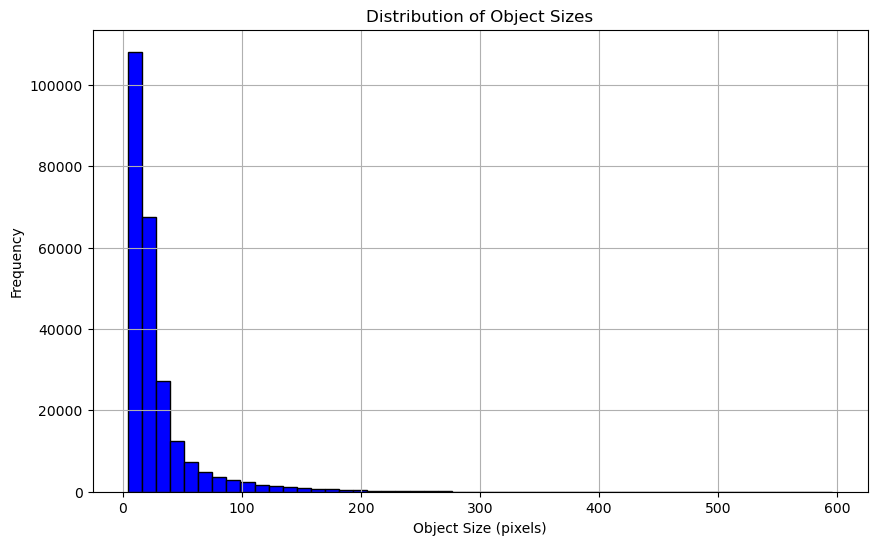

In [4]:
import zipfile
import os
from skimage import io, measure
import matplotlib.pyplot as plt
import numpy as np

# Define the path to the zip file
zip_path = "/scr/data/micronuclei-screen/prob-maps/plate_5/prob-maps.zip"
extraction_path = "/scr/data/micronuclei-screen/prob-maps/plate_5"
extracted_path = "/scr/data/micronuclei-screen/prob-maps/plate_5/prob-maps"


# Unzip the file
#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#    zip_ref.extractall(extraction_path)

# List all image files in the extracted folder
image_files = [f for f in os.listdir(extracted_path) if f.endswith(('.png', '.tif', '.jpg', '.npy'))]


# List to hold the sizes of all objects
object_sizes = []

# Iterate over each image file
for image_file in image_files:
    print("processing", image_file)
    # Load the image
    image_path = os.path.join(extracted_path, image_file)
    image = np.load(image_path, allow_pickle=True)

    # Label the image
    label_image = measure.label(image)
    
    # Measure properties of labeled regions
    properties = measure.regionprops(label_image)
    
    # Extract the size of each object
    for prop in properties:
        object_sizes.append(prop.area)

# Create a histogram of object sizes
plt.figure(figsize=(10, 6))
plt.hist(object_sizes, bins=50, color='blue', edgecolor='black')
plt.title('Distribution of Object Sizes')
plt.xlabel('Object Size (pixels)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
